
Iris – shape: (150, 4), classes: [0, 1, 2]
                   non‑zero %      mean       std  min  max
sepal length (cm)       100.0  5.843333  0.828066  4.3  7.9
sepal width (cm)        100.0  3.057333  0.435866  2.0  4.4
petal length (cm)       100.0  3.758000  1.765298  1.0  6.9
petal width (cm)        100.0  1.199333  0.762238  0.1  2.5
target                    NaN  1.000000  0.819232  0.0  2.0

Wine – shape: (178, 13), classes: [0, 1, 2]
                   non‑zero %       mean        std    min     max
alcohol                 100.0  13.000618   0.811827  11.03   14.83
malic_acid              100.0   2.336348   1.117146   0.74    5.80
ash                     100.0   2.366517   0.274344   1.36    3.23
alcalinity_of_ash       100.0  19.494944   3.339564  10.60   30.00
magnesium               100.0  99.741573  14.282484  70.00  162.00

Digits – shape: (1797, 64), classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
           non‑zero %       mean       std  min   max
pixel_0_0    0.000000   0.

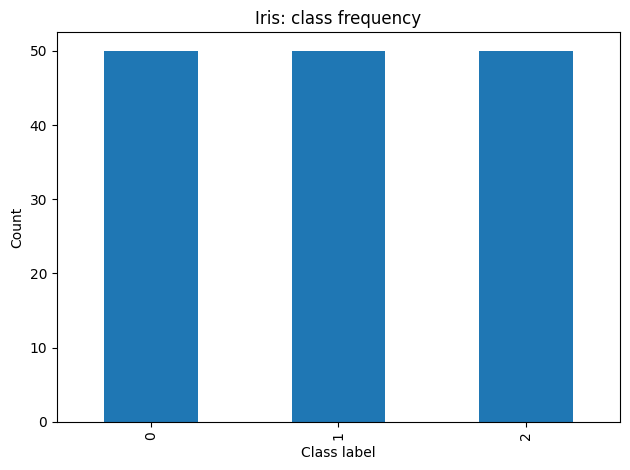

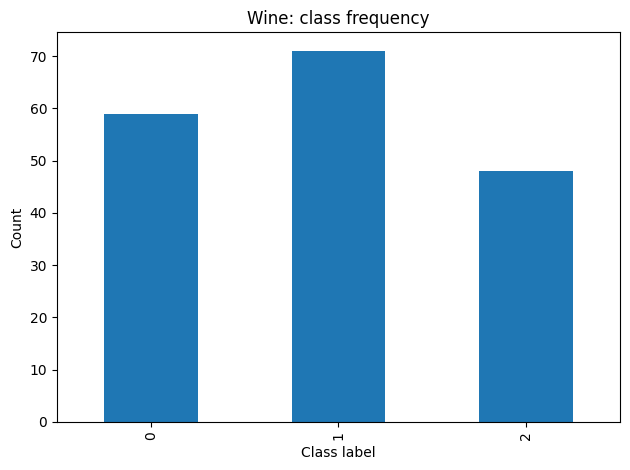

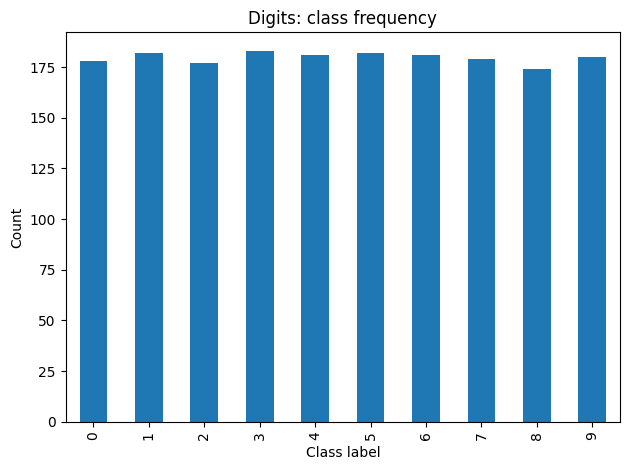

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, load_digits
from sklearn.preprocessing import StandardScaler

def summarize_dataset(name, data_bunch, target_name='target'):
    X = pd.DataFrame(data_bunch.data, columns=data_bunch.feature_names if hasattr(data_bunch, 'feature_names') else [f'feat_{i}' for i in range(data_bunch.data.shape[1])])
    y = pd.Series(data_bunch.target, name=target_name)
    df = pd.concat([X, y], axis=1)
    summary = df.describe().T[['mean', 'std', 'min', 'max']]
    summary.insert(0, 'non‑zero %', (X != 0).sum(axis=0)/len(X)*100)
    print(f"\n{name} – shape: {X.shape}, classes: {y.unique().tolist()}")
    print(summary.head())
    # class frequency plot
    plt.figure()
    y.value_counts().sort_index().plot(kind='bar')
    plt.title(f"{name}: class frequency")
    plt.xlabel("Class label")
    plt.ylabel("Count")
    plt.tight_layout()

# Load datasets
iris = load_iris()
wine = load_wine()
digits = load_digits()

summarize_dataset('Iris', iris)
summarize_dataset('Wine', wine)
summarize_dataset('Digits', digits)

plt.show()


In [8]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline

def evaluate(name, bunch, scale):
    X, y = bunch.data, bunch.target

    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    records = []
    for p, label in [(1, 'L1 (Manhattan)'), (2, 'L2 (Euclidean)')]:
        steps = []
        if scale:
            steps.append(('scaler', StandardScaler()))
        steps.append(('knn', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=p)))
        pipe = make_pipeline(*[s[1] if isinstance(s, tuple) else s for s in steps])
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
        records.append({'Dataset': name,
                        'Norm': label,
                        'Accuracy Mean': scores.mean(),
                        'Accuracy SD': scores.std()})
    return records

results = []
results += evaluate('Iris', load_iris(), scale=False)
results += evaluate('Wine', load_wine(), scale=True)
results += evaluate('Digits', load_digits(), scale=True)

df = pd.DataFrame(results)
print(df)


  Dataset            Norm  Accuracy Mean  Accuracy SD
0    Iris  L1 (Manhattan)       0.946667     0.058119
1    Iris  L2 (Euclidean)       0.953333     0.052068
2    Wine  L1 (Manhattan)       0.966667     0.056656
3    Wine  L2 (Euclidean)       0.972222     0.044790
4  Digits  L1 (Manhattan)       0.977737     0.012190
5  Digits  L2 (Euclidean)       0.978845     0.011375
